In [3]:
import pandas as pd
import numpy as np
import seaborn as sns

In [2]:
behav_df = pd.read_csv('behav_summary_mri.csv')

In [3]:
behav_df.head()

,subjectNumber,trialNinBlock,effort,effortLevel,response,RT,forceData,timeInWindow,reward,blockType,blockNumber,trialN,responseHistory,exertedEffortHistory,predictedEffortHistory,rewardHistory,averageRR,averageEffortRate
0,1,1,333,0.6,0,0.890922,NaN,NaN,0,99,1,1,NaN,NaN,NaN,0,4.0,0.4
1,1,2,222,0.4,1,0.641609,4851.563263,1.874732,3,99,1,2,0.0,0.0,0.6,0,4.0,0.4
2,1,3,333,0.6,0,0.837105,NaN,NaN,0,99,1,3,1.0,0.4,0.4,3,4.0,0.4
3,1,4,333,0.6,0,0.599812,NaN,NaN,0,99,1,4,0.0,0.0,0.6,0,4.0,0.4
4,1,5,111,0.2,1,0.612520,3436.058197,2.456701,4,99,1,5,0.0,0.0,0.6,0,4.0,0.4


In [4]:
# Step 1: Exclude missed trials 
filtered_df = behav_df[behav_df['response'] != 8888]

# Step 2: Calculate the mean response for each subject
subject_accept_all_exclude = filtered_df.groupby('subjectNumber')['response'].mean().reset_index()
subject_accept_all_exclude.columns = ['subjectNumber', 'mean_response']

# Step 3: Identify subjects to exclude (mean response > 0.95)
subjects_to_exclude_accept_all = subject_accept_all_exclude[subject_accept_all_exclude['mean_response'] > 0.95]['subjectNumber']
print("subject that accepted all:", list(subjects_to_exclude_accept_all))

# Step 4: Calculate the proportion of 8888 responses for each subject
missed_many = behav_df.groupby('subjectNumber')['response'].apply(lambda x: (x == 8888).mean()).reset_index()
missed_many.columns = ['subjectNumber', 'missed']

# Step 5: Identify subjects to exclude (missed > 0.1)
subjects_to_exclude_missed = missed_many[missed_many['missed'] > 0.1]['subjectNumber']
print("subject that missed more than 10% of the trials:", list(subjects_to_exclude_missed))

# Combine all subjects to exclude
subjects_to_exclude = pd.concat([subjects_to_exclude_accept_all, subjects_to_exclude_missed]).drop_duplicates()
print(list(subjects_to_exclude))

# Step 6: Exclude those subjects from the original dataframe
behav_data = filtered_df[~filtered_df['subjectNumber'].isin(subjects_to_exclude)]

# Display the cleaned dataframe
behav_data.head()

subject that accepted all: [10]
subject that missed more than 10% of the trials: []
[10]


,subjectNumber,trialNinBlock,effort,effortLevel,response,RT,forceData,timeInWindow,reward,blockType,blockNumber,trialN,responseHistory,exertedEffortHistory,predictedEffortHistory,rewardHistory,averageRR,averageEffortRate
0,1,1,333,0.6,0,0.890922,NaN,NaN,0,99,1,1,NaN,NaN,NaN,0,4.0,0.4
1,1,2,222,0.4,1,0.641609,4851.563263,1.874732,3,99,1,2,0.0,0.0,0.6,0,4.0,0.4
2,1,3,333,0.6,0,0.837105,NaN,NaN,0,99,1,3,1.0,0.4,0.4,3,4.0,0.4
3,1,4,333,0.6,0,0.599812,NaN,NaN,0,99,1,4,0.0,0.0,0.6,0,4.0,0.4
4,1,5,111,0.2,1,0.612520,3436.058197,2.456701,4,99,1,5,0.0,0.0,0.6,0,4.0,0.4


In [5]:
behav_data['subjectNumber'].unique()

array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 11, 12, 13, 14, 15, 16, 17, 18])

In [6]:
# Calculate the accept rates
accept_rate = behav_data.groupby(['effortLevel', 'blockType'])['response'].mean().reset_index()
accept_rate.columns = ['effortLevel', 'blockType', 'accept_rate']

In [7]:
accept_rate

,effortLevel,blockType,accept_rate
0,0.2,11,0.994444
1,0.2,99,0.994382
2,0.4,11,0.662338
3,0.4,99,0.862915
4,0.6,11,0.130159
5,0.6,99,0.171920


In [8]:
# Calculate the standard error for error bars
accept_rate['std_error'] = behav_data.groupby(['effortLevel', 'blockType'])['response'].sem().reset_index()['response']

In [9]:
# Map effort levels and block types to meaningful names
effort_map = {0.2: 'Low', 0.4: 'Mid', 0.6: 'High'}
block_map = {11: 'Easy', 99: 'Hard'}

accept_rate['effortLevel'] = accept_rate['effortLevel'].map(effort_map)
accept_rate['blockType'] = accept_rate['blockType'].map(block_map)

In [10]:
accept_rate

,effortLevel,blockType,accept_rate,std_error
0,Low,Easy,0.994444,0.002479
1,Low,Hard,0.994382,0.003967
2,Mid,Easy,0.662338,0.019070
3,Mid,Hard,0.862915,0.013075
4,High,Easy,0.130159,0.018989
5,High,Hard,0.171920,0.011666


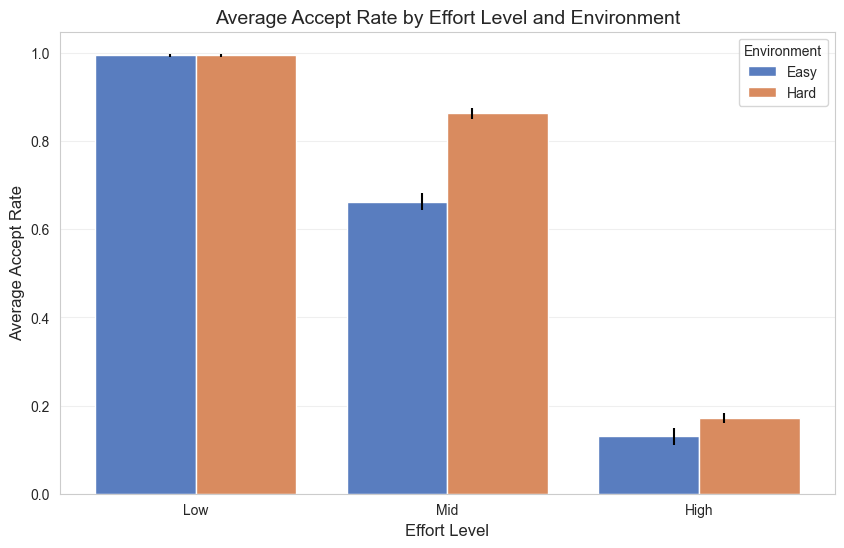

In [11]:
# Plotting
plt.figure(figsize=(10, 6))
sns.barplot(data=accept_rate, x='effortLevel', y='accept_rate', hue='blockType', errorbar=None, capsize=0.1, palette='muted')

# Adding error bars manually
for i in range(len(accept_rate)):
    plt.errorbar(x=i//2 + i%2*0.2 - 0.1, y=accept_rate['accept_rate'][i], yerr=accept_rate['std_error'][i], fmt='none', c='black')

plt.xlabel('Effort Level')
plt.ylabel('Average Accept Rate')
plt.title('Average Accept Rate by Effort Level and Environment')
plt.legend(title='Environment')
plt.show()

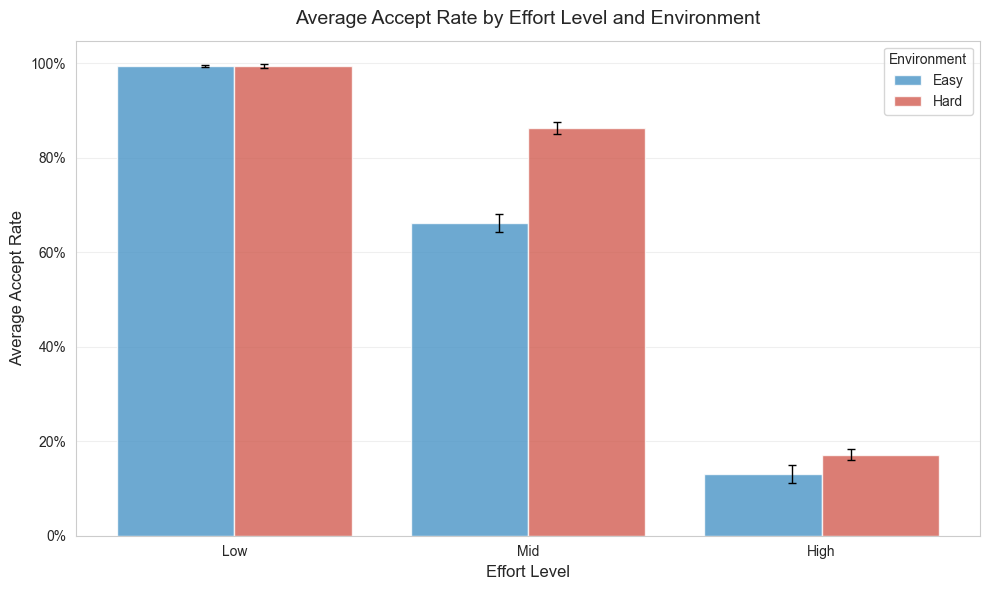

In [14]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming accept_rate is your DataFrame
# If not, you'll need to create it or load it here

# Set the style
sns.set_style("whitegrid")

# Define custom colors
custom_colors = ['#3498db', '#e74c3c']

# Adjust gridline transparency
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

# Set font sizes
SMALL_SIZE = 10
MEDIUM_SIZE = 12
LARGE_SIZE = 14

# Apply font sizes
plt.rc('font', size=SMALL_SIZE)
plt.rc('axes', titlesize=LARGE_SIZE)
plt.rc('axes', labelsize=MEDIUM_SIZE)
plt.rc('xtick', labelsize=SMALL_SIZE)
plt.rc('ytick', labelsize=SMALL_SIZE)
plt.rc('legend', fontsize=SMALL_SIZE)

# Create the plot
plt.figure(figsize=(10, 6))
bar_plot = sns.barplot(data=accept_rate, x='effortLevel', y='accept_rate', hue='blockType', 
                       errorbar=None, capsize=0.1, palette=custom_colors, alpha=0.8)

# Adding error bars manually
for i, row in accept_rate.iterrows():
    x = i // 2 + (i % 2) * 0.2 - 0.1
    plt.errorbar(x=x, y=row['accept_rate'], yerr=row['std_error'], 
                 fmt='none', c='black', capsize=3, elinewidth=1, capthick=1)

# Customize the plot
plt.xlabel('Effort Level', fontsize=MEDIUM_SIZE)
plt.ylabel('Average Accept Rate', fontsize=MEDIUM_SIZE)
plt.title('Average Accept Rate by Effort Level and Environment', fontsize=LARGE_SIZE, pad=12)
plt.legend(title='Environment', title_fontsize=SMALL_SIZE, loc='upper right', bbox_to_anchor=(1, 1))

# Adjust y-axis to start from 0
plt.ylim(0, plt.ylim()[1])

# Add percentage to y-axis
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f"{x:.0%}"))

# Adjust layout and display the plot
plt.tight_layout()
plt.savefig('accept_rate_by_effort_and_environment.png', dpi=300, bbox_inches='tight')
plt.show()

# LLM

In [115]:
import pandas as pd
import statsmodels.formula.api as smf

In [138]:
# Ensure the DataFrame is correctly formatted
behav_data_copy = behav_data.copy()


# Convert categorical columns to string types for analysis
behav_data_copy['effortLevel'] = behav_data_copy['effortLevel'].astype('category')
behav_data_copy['blockType'] = behav_data_copy['blockType'].astype('category')
behav_data_copy['response'] = behav_data_copy['response'].astype('int')

# Define the linear mixed model formula
formula = 'response ~ effortLevel * blockType + (1|subjectNumber)'

# Fit the LMM model
model = smf.mixedlm(formula, data=behav_data_copy, groups=behav_data_copy['subjectNumber'])
result = model.fit(reml=False, method='lbfgs', maxiter=1e6)


# Display the summary of the model
print(result.summary())

                    Mixed Linear Model Regression Results
Model:                     MixedLM        Dependent Variable:        response 
No. Observations:          3265           Method:                    ML       
No. Groups:                14             Scale:                     0.0857   
Min. group size:           194            Log-Likelihood:            -648.9031
Max. group size:           280            Converged:                 Yes      
Mean group size:           233.2                                              
------------------------------------------------------------------------------
                                   Coef.  Std.Err.    z    P>|z| [0.025 0.975]
------------------------------------------------------------------------------
Intercept                           1.007    0.076  13.171 0.000  0.857  1.156
effortLevel[T.0.4]                 -0.354    0.017 -21.049 0.000 -0.387 -0.321
effortLevel[T.0.6]                 -0.867    0.021 -41.222 0.000 -0.908 -

/Users/proghani/miniforge3/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:1634: UserWarning: Random effects covariance is singular
  warnings.warn(msg)


Let's break down the results of the mixed linear model and address why the effort level 0.2 is not explicitly shown.

### Interpretation of the Results

1. **Intercept**:
   - **Coef.**: 1.007
   - **Std.Err.**: 0.082
   - **z**: 12.204
   - **P>|z|**: 0.000
   - **95% CI**: [0.845, 1.168]
   
   The intercept represents the expected response when all predictors are at their reference levels (effortLevel 0.2 and blockType 11). The coefficient of 1.007 indicates a positive log-odds of accepting the effort level of 0.2 in the easy environment.

2. **effortLevel[T.0.4]**:
   - **Coef.**: -0.354
   - **Std.Err.**: 0.017
   - **z**: -21.033
   - **P>|z|**: 0.000
   - **95% CI**: [-0.387, -0.321]
   
   The coefficient for effortLevel 0.4 is -0.354, which means that compared to effortLevel 0.2, the log-odds of accepting the task are reduced by 0.354 when the effort level is 0.4.

3. **effortLevel[T.0.6]**:
   - **Coef.**: -0.867
   - **Std.Err.**: 0.021
   - **z**: -41.191
   - **P>|z|**: 0.000
   - **95% CI**: [-0.908, -0.826]
   
   The coefficient for effortLevel 0.6 is -0.867, indicating a further reduction in the log-odds of accepting the task by 0.867 compared to effortLevel 0.2.

4. **blockType[T.99]**:
   - **Coef.**: 0.004
   - **Std.Err.**: 0.020
   - **z**: 0.180
   - **P>|z|**: 0.857
   - **95% CI**: [-0.036, 0.043]
   
   The coefficient for blockType 99 (hard environment) is 0.004, which is not statistically significant (p-value = 0.857). This suggests that, on its own, the block type does not have a significant effect on the log-odds of accepting the task.

5. **effortLevel[T.0.4]:blockType[T.99]**:
   - **Coef.**: 0.199
   - **Std.Err.**: 0.027
   - **z**: 7.396
   - **P>|z|**: 0.000
   - **95% CI**: [0.146, 0.251]
   
   The interaction term between effortLevel 0.4 and blockType 99 has a positive coefficient of 0.199, which is statistically significant (p-value = 0.000). This indicates that the reduction in the log-odds of accepting the task at effortLevel 0.4 is less severe in the hard environment compared to the easy environment.

6. **effortLevel[T.0.6]:blockType[T.99]**:
   - **Coef.**: 0.018
   - **Std.Err.**: 0.029
   - **z**: 0.636
   - **P>|z|**: 0.525
   - **95% CI**: [-0.038, 0.075]
   
   The interaction term between effortLevel 0.6 and blockType 99 is not statistically significant (p-value = 0.525), indicating that the effect of effortLevel 0.6 on the log-odds of accepting the task is similar in both environments.

7. **1 | subjectNumber** and **Group Var**:
   - **Group Var** represents the variance of the random intercepts for each subject. A variance of 0.021 indicates some variability in the intercepts across subjects, but not very high.

### Why Effort Level 0.2 is Not Explicitly Shown
In regression models, one level of each categorical variable is usually chosen as the reference category. The coefficients for the other levels of the categorical variable are interpreted relative to this reference category. In this case, effort level 0.2 is the reference category for the `effortLevel` variable. This means:

- The intercept represents the log-odds of acceptance for effort level 0.2 in the easy environment (blockType 11).
- The coefficients for `effortLevel[T.0.4]` and `effortLevel[T.0.6]` represent the difference in log-odds of acceptance compared to the reference category (effort level 0.2).

### Summary
- Effort level has a significant effect on the probability of accepting a task, with higher effort levels reducing the log-odds of acceptance.
- The interaction between effort level 0.4 and the hard environment is significant, suggesting that the reduction in acceptance rate at effort level 0.4 is less severe in the hard environment.
- The block type alone does not have a significant effect, nor does the interaction between effort level 0.6 and block type.

### The interaction effect of effort level 0.2 and block type
The interaction effect of effort level 0.2 and block type (easy vs. hard environment) is not directly shown in the results because effort level 0.2 is used as the reference category. In mixed models, the interaction terms involving the reference category are implicitly included in the intercept and the main effects.

To understand the effect of effort level 0.2 and block type interaction, we should look at the intercept and the main effect of block type:

1. **Intercept**: Represents the log-odds of accepting the task for effort level 0.2 in the easy environment (block type 11).
2. **blockType[T.99]**: Represents the difference in the log-odds of accepting the task for effort level 0.2 between the hard environment (block type 99) and the easy environment (block type 11).

Given the model results:
- **Intercept**: 1.007 (log-odds of accepting for effort level 0.2 in the easy environment)
- **blockType[T.99]**: 0.004 (difference in log-odds between hard and easy environment for effort level 0.2)

The coefficient for `blockType[T.99]` is 0.004, which means that there is a very small and non-significant (p-value = 0.857) difference in the log-odds of accepting the task at effort level 0.2 between the hard and easy environments. This suggests that for effort level 0.2, the environment (easy or hard) does not have a significant impact on the probability of acceptance.

### Summary
For effort level 0.2:
- The environment (easy vs. hard) does not significantly affect the probability of acceptance.
- The log-odds of acceptance are almost the same in both environments, as indicated by the non-significant and near-zero coefficient for the block type effect.

This interpretation aligns with the provided coefficients and their significance levels, confirming that the environment does not play a significant role in determining the acceptance rate for the lowest effort level.

In [147]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import patsy
from scipy.optimize import minimize
from sklearn.utils import resample

# Ensure the DataFrame is correctly formatted
behav_data_copy = behav_data.copy()

# Convert categorical columns to string types for analysis
behav_data_copy['effortLevel'] = behav_data_copy['effortLevel'].astype('category')
behav_data_copy['blockType'] = behav_data_copy['blockType'].astype('category')
behav_data_copy['response'] = behav_data_copy['response'].astype('int')

# Define the formula for fixed effects and random effects
fixed_effects_formula = 'response ~ effortLevel * blockType'
random_effects_formula = '1|subjectNumber'

# Create the design matrices using patsy
y, X = patsy.dmatrices(fixed_effects_formula, data=behav_data_copy, return_type='dataframe')
Z = patsy.dmatrix(random_effects_formula, data=behav_data_copy, return_type='dataframe')

# Define the log-likelihood function for the binomial GLMM
def loglike(params, y, X, Z):
    beta = params[:X.shape[1]]
    u = params[X.shape[1]:]
    eta = X @ beta + Z @ u
    mu = 1 / (1 + np.exp(-eta))
    loglike = y * np.log(mu) + (1 - y) * np.log(1 - mu)
    return -np.sum(loglike)

# Initial parameter values
params_init = np.zeros(X.shape[1] + Z.shape[1])

# Optimize the log-likelihood function
result = minimize(loglike, params_init, args=(behav_data_copy['response'], X, Z), method='L-BFGS-B')

# Extract the results
beta_hat = result.x[:X.shape[1]]
u_hat = result.x[X.shape[1]:]

# Bootstrapping to estimate standard errors
n_bootstraps = 100
bootstrap_estimates = np.zeros((n_bootstraps, len(beta_hat)))

for i in range(n_bootstraps):
    # print(i)
    sample = resample(behav_data_copy)
    y_boot, X_boot = patsy.dmatrices(fixed_effects_formula, data=sample, return_type='dataframe')
    Z_boot = patsy.dmatrix(random_effects_formula, data=sample, return_type='dataframe')
    
    result_boot = minimize(loglike, params_init, args=(sample['response'], X_boot, Z_boot), method='L-BFGS-B')
    bootstrap_estimates[i, :] = result_boot.x[:X.shape[1]]

# Calculate standard errors
bootstrap_se = np.std(bootstrap_estimates, axis=0)

/Users/proghani/miniforge3/lib/python3.10/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
/Users/proghani/miniforge3/lib/python3.10/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
/Users/proghani/miniforge3/lib/python3.10/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
/Users/proghani/miniforge3/lib/python3.10/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
/Users/proghani/miniforge3/lib/python3.10/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
/Users/proghani/miniforge3/lib/python3.10/site-packages

In [148]:
# Calculate z-scores and p-values
z_scores = beta_hat / bootstrap_se
p_values = 2 * (1 - stats.norm.cdf(np.abs(z_scores)))


# Print the results
print(f"Fixed effects coefficients:\n{beta_hat}")
print(f"Standard errors:\n{bootstrap_se}")
print(f"z-scores:\n{z_scores}")
print(f"p-values:\n{p_values}")

Fixed effects coefficients:
[ 2.4003476  -4.41970519 -6.90952523  0.69458884  0.40533358 -0.56317667]
Standard errors:
[0.64513641 1.29132993 1.28424926 5.55762617 5.58230178 5.56353104]
z-scores:
[ 3.72068225 -3.42259952 -5.38020575  0.12497941  0.07261047 -0.10122648]
p-values:
[1.98685299e-04 6.20253872e-04 7.44007562e-08 9.00539851e-01
 9.42116091e-01 9.19370676e-01]


# GLLM

In [84]:
# !pip install pymer4


In [149]:
# import pandas as pd
# from pymer4.models import Lmer
# import seaborn as sns
# import matplotlib.pyplot as plt

# # Ensure the DataFrame is correctly formatted
# behav_data_copy = behav_data.copy()

# # Convert categorical columns to category types for analysis
# behav_data_copy['effortLevel'] = behav_data_copy['effortLevel'].astype(str).astype('category')
# behav_data_copy['blockType'] = behav_data_copy['blockType'].astype(str).astype('category')
# behav_data_copy['response'] = behav_data_copy['response'].astype('int')


# # Define the GLMM formula
# formula = 'response ~ effortLevel * blockType + (1|subjectNumber)'

# # Fit the model
# model = Lmer(formula, data=behav_data_copy, family='binomial')
# result = model.fit()

# # Display the summary of the model
# result


# ANOVA

In [99]:
import pandas as pd

# Ensure the DataFrame is correctly formatted
behav_data_copy = cleaned_df.copy()

# Convert categorical columns to string types before converting to categories
behav_data_copy['effortLevel'] = behav_data_copy['effortLevel'].astype(str).astype('category')
behav_data_copy['blockType'] = behav_data_copy['blockType'].astype(str).astype('category')
behav_data_copy['response'] = behav_data_copy['response'].astype('int')

# Aggregate the data to get the mean response for each subject, effort level, and block type combination
aggregated_data = behav_data_copy.groupby(['subjectNumber', 'effortLevel', 'blockType'])['response'].mean().reset_index()


/var/folders/n7/g8bq81dn5879t8lq7djjjst40000gn/T/ipykernel_72825/2270741923.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  aggregated_data = behav_data_copy.groupby(['subjectNumber', 'effortLevel', 'blockType'])['response'].mean().reset_index()


### Perform the Mixed-Effects ANOVA

In [100]:
from statsmodels.stats.anova import AnovaRM

# Fit the model for ANOVA
model = AnovaRM(aggregated_data, 'response', 'subjectNumber', within=['effortLevel', 'blockType'])
anova_results = model.fit()

# Display the results
print(anova_results)


                       Anova
                      F Value Num DF  Den DF Pr > F
---------------------------------------------------
effortLevel           91.9213 2.0000 26.0000 0.0000
blockType              9.8256 1.0000 13.0000 0.0079
effortLevel:blockType  5.6701 2.0000 26.0000 0.0090



### Interpretation of the Mixed-Effects ANOVA Results

The mixed-effects ANOVA results are summarized as follows:

| Effect                   | F Value  | Num DF | Den DF | Pr > F |
|--------------------------|----------|--------|--------|--------|
| effortLevel              | 91.9213  | 2.0000 | 26.0000| 0.0000 |
| blockType                |  9.8256  | 1.0000 | 13.0000| 0.0079 |
| effortLevel:blockType    |  5.6701  | 2.0000 | 26.0000| 0.0090 |

### Detailed Interpretation

1. **effortLevel**:
   - **F Value**: 91.9213
   - **Degrees of Freedom (Num DF, Den DF)**: 2.0000, 26.0000
   - **p-value (Pr > F)**: 0.0000

   **Interpretation**: The main effect of `effortLevel` is highly significant (p < 0.001). This indicates that there are significant differences in the accept rates across different effort levels (Low, Mid, High).

2. **blockType**:
   - **F Value**: 9.8256
   - **Degrees of Freedom (Num DF, Den DF)**: 1.0000, 13.0000
   - **p-value (Pr > F)**: 0.0079

   **Interpretation**: The main effect of `blockType` (environment: Easy vs. Hard) is significant (p < 0.01). This indicates that there is a significant difference in the accept rates between the two environments.

3. **effortLevel:blockType**:
   - **F Value**: 5.6701
   - **Degrees of Freedom (Num DF, Den DF)**: 2.0000, 26.0000
   - **p-value (Pr > F)**: 0.0090

   **Interpretation**: The interaction effect between `effortLevel` and `blockType` is significant (p < 0.01). This indicates that the effect of effort level on accept rates depends on the environment. In other words, the difference in accept rates across effort levels is not consistent between the easy and hard environments.

### Summary

- The significant main effect of `effortLevel` suggests that the accept rates vary significantly across different effort levels.
- The significant main effect of `blockType` indicates that the environment (easy vs. hard) significantly affects accept rates.
- The significant interaction effect between `effortLevel` and `blockType` implies that the impact of effort level on accept rates is different depending on the environment. This is consistent with your observation in the bar chart where the accept rates for the mid-effort level (0.4) differed notably between the two environments.

These results confirm that the visual differences observed in the bar chart are statistically significant, and the interaction between effort level and environment plays an important role in determining accept rates.

### Post-hoc pairwise comparisons
Post-hoc pairwise comparisons are essential to understand which specific groups differ from each other after finding a significant interaction effect in ANOVA.
Tukey’s HSD test is a robust method for performing these comparisons and adjusting for multiple comparisons.

In [103]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# Ensure the DataFrame is correctly formatted
behav_data_copy = cleaned_df.copy()

# Convert categorical columns to string types before converting to categories
behav_data_copy['effortLevel'] = behav_data_copy['effortLevel'].astype(str)
behav_data_copy['blockType'] = behav_data_copy['blockType'].astype(str)
behav_data_copy['response'] = behav_data_copy['response'].astype(int)

# Create a combined factor for interaction analysis
behav_data_copy['effortLevel_blockType'] = behav_data_copy['effortLevel'] + '_' + behav_data_copy['blockType']

# Perform Tukey's HSD test
tukey = pairwise_tukeyhsd(endog=behav_data_copy['response'], groups=behav_data_copy['effortLevel_blockType'], alpha=0.05)

# Print the results
print(tukey.summary())

Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower   upper  reject
----------------------------------------------------
0.2_11 0.2_99   0.0034    1.0 -0.0597  0.0664  False
0.2_11 0.4_11  -0.3521    0.0 -0.4049 -0.2993   True
0.2_11 0.4_99  -0.1504    0.0 -0.2013 -0.0995   True
0.2_11 0.6_11  -0.8635    0.0 -0.9295 -0.7975   True
0.2_11 0.6_99  -0.8478    0.0 -0.8936  -0.802   True
0.2_99 0.4_11  -0.3555    0.0 -0.4225 -0.2884   True
0.2_99 0.4_99  -0.1538    0.0 -0.2194 -0.0882   True
0.2_99 0.6_11  -0.8669    0.0 -0.9447  -0.789   True
0.2_99 0.6_99  -0.8512    0.0 -0.9129 -0.7895   True
0.4_11 0.4_99   0.2017    0.0  0.1459  0.2574   True
0.4_11 0.6_11  -0.5114    0.0 -0.5812 -0.4416   True
0.4_11 0.6_99  -0.4957    0.0 -0.5469 -0.4445   True
0.4_99 0.6_11  -0.7131    0.0 -0.7814 -0.6447   True
0.4_99 0.6_99  -0.6974    0.0 -0.7466 -0.6481   True
0.6_11 0.6_99   0.0157 0.9829  -0.049  0.0804  False
----------------------------------------------

/var/folders/n7/g8bq81dn5879t8lq7djjjst40000gn/T/ipykernel_72825/912802942.py:4: FutureWarning: 

The `errwidth` parameter is deprecated. And will be removed in v0.15.0. Pass `err_kws={'linewidth': 1}` instead.

  sns.pointplot(data=behav_data_copy, x='effortLevel', y='response', hue='blockType', dodge=True, markers=['o', 's'], capsize=0.1, errwidth=1, palette='colorblind')


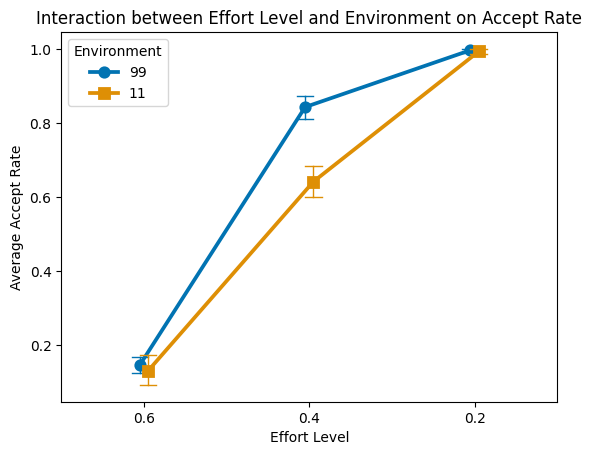

In [104]:
import matplotlib.pyplot as plt

# Plot the interaction plot
sns.pointplot(data=behav_data_copy, x='effortLevel', y='response', hue='blockType', dodge=True, markers=['o', 's'], capsize=0.1, errwidth=1, palette='colorblind')

plt.xlabel('Effort Level')
plt.ylabel('Average Accept Rate')
plt.title('Interaction between Effort Level and Environment on Accept Rate')
plt.legend(title='Environment')
plt.show()